# Deep Learining Ansatz

Im folgenden Notebook werden mögliche Deep Learining Ansätze angeschaut um unser Problem zu lösen. Das Ziel ist ein Modell zu finden was idealerweise 0.8 als Macro F1-Score auf Test hat. 

In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import wandb
from sklearn.metrics import f1_score
from tqdm import tqdm

# Daten

Es wird mit 50Hz Daten gearbeitet, welche durch Sliding Window auf Windowsize 100 und einen Overlap von 50 bearbeitet wurden. Die genauere Erklärung dazu befindet sich in den EDA-Notebooks. Die aktuellsten Daten sind die richtig gesplitteten Daten ohne Dataleakage durch gleiche Personen in Train und Test. Jedoch wurde zu Beginn dieses Notebooks noch alte Datenaufteilungen verwendet. Die vorgehigen Ergebnisse sind auf WanDB gespeichert und mit Versionen gekennzeichnet. Die Namensgebungen werden später noch genauer erläutert. 

In [2]:
# .npz laden
train = np.load("../Model_data/train_split1_100WS.npz")
test  = np.load("../Model_data/test_split1_100WS.npz")

X_train, y_train = train["X"], train["y"]
X_test,  y_test  = test["X"],  test["y"]

# X_train hat die Form (Anzahl Windows, Zeitschritte pro Window, Anzahl Features)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(21167, 100, 13)
(21167,)
(3969, 100, 13)
(3969,)


In [3]:
# PyTorch braucht numerische Klassen
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# NumPy zu PyTorch Tensoren und umformen zu (N, 13, 100) (Chanels in der Mitte) für CNN, nicht bei LSTM
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).permute(0, 2, 1)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

# Datasets erstellen als Tensoren
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

# Für LSTM ist kein permute nötig (N, Zeit, Features)
X_train_lstm = torch.tensor(X_train, dtype=torch.float32)  # (N, 100, 13)
X_test_lstm  = torch.tensor(X_test,  dtype=torch.float32)

train_ds_lstm = TensorDataset(X_train_lstm, y_train_t)
test_ds_lstm  = TensorDataset(X_test_lstm,  y_test_t)

# GPU falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\jessi\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

# Modelle

Als erstes wurde nur ein 1D-CNN implementiert, erst im Verlauf noch weitere Modelle hinzugefügt. Die LSTM Ansätze sind alle nur mit dem richtigen Datensplit erstellt worden. Die vorgängige Version des 1D-CNNs mit Residual Blöcken kann in der Githistory genauer gesucht werden.

Da das LSTM bessere Ergebnisse erzielen konnte, wie das Bidirektionale LSTM wurde dies noch versucht mit Self Attention zu verbessern. Dazu findet man unter "LSTM Ansatz" mehr.

In [5]:
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.net(x))
    

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),  # Dropout direkt nach Aktivierung
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class CNN1D_Residual(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.3):
        super().__init__()
        
        # Stem: breiterer Kernel für längere Zeitabhängigkeiten
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        
        # Block 1: 64 Kanäle
        self.res1a = ResidualBlock(64, dropout)
        self.res1b = ResidualBlock(64, dropout)
        
        # Downsampling 64 -> 128
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        
        # Block 2: 128 Kanäle
        self.res2a = ResidualBlock(128, dropout)
        self.res2b = ResidualBlock(128, dropout)
        
        # Downsampling 128 -> 256
        self.down2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )
        
        # Block 3: 256 Kanäle 
        self.res3 = ResidualBlock(256, dropout)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Grösserer Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res1a(x)
        x = self.res1b(x)
        x = self.down1(x)
        x = self.res2a(x)
        x = self.res2b(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.pool(x)
        return self.classifier(x)
    

class LSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128, 
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,     
            hidden_size=hidden_size,    # Anzahl LSTM-Units pro Layer
            num_layers=num_layers,      # Gestapelte LSTM-Schichten
            batch_first=True,           # Erwartet (N, Zeit, Features)
            dropout=dropout if num_layers > 1 else 0,  # nur zwischen Layers
            bidirectional=False
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (N, 100, 13)
        out, (h_n, c_n) = self.lstm(x)
        # Nur den letzten Zeitschritt verwenden
        last = out[:, -1, :]            # (N, hidden_size)
        return self.classifier(last)

# Bidirektionaler Ansatz
class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True           # vorwärts + rückwärts
        )
        # bidirectional verdoppelt die Output-Grösse
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]            # (N, hidden_size * 2)
        return self.classifier(last)
    
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out: (N, T, hidden_size)
        weights = torch.softmax(self.attn(lstm_out), dim=1)  # (N, T, 1)
        return (lstm_out * weights).sum(dim=1)                # (N, hidden_size)
    
class LSTMAttentionClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=256,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.attention = Attention(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        context = self.attention(out)    # gewichteter Durchschnitt statt letzter Schritt
        return self.classifier(context)

class CNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),              # 100 → 50
        )
        self.res = ResidualBlock(64, dropout)   # dein bestehender ResidualBlock

        self.down = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
                                          # kein MaxPool → bleibt bei 50
        )
        
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (N, T, C) → (N, C, T)
        x = self.stem(x)
        x = self.res(x)
        x = self.down(x)                 # (N, 128, 50)
        x = x.permute(0, 2, 1)          # (N, 50, 128)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(last)

## Namensgebungen

Die Bezeichnungen der Durchläufe haben sich im Laufe der Zeit geändert z.B. 1D-CNN_v3...

Die verschiedenen Versionen sind:

- Version 1 war ohne Datenaugmentierung und andere Verfeinerungen mit hohen Datenleakage
- Version 2 nutzt Datenaugmentierung und ein Learningrate scheduler eingebaut, verwendet aber noch die alte Datenaufteilung
- Version 3 nutzt die nächste Aufteilung in Trainings- und Testdaten, bei der wir die Daten nach Benutzern getrennt haben und nur noch minimales Datenleakage vorhanden ist.
- Version 4 hat label_smoothing=0.1 im criterion, mehr Daten Agumentation und hat eine eingebauten ResidualBlock (Skipconnection) wegen Vanashing Gradient
- Version 5 neuer Split mit besserer Aufteilung der Personen auf die Klassen ohne Überschneidungen, dieser diente für die finale Evaluation
- Version 6 Tieferes Netzwerk im 1D-CNN Residual und erweiterung der Daten Augmentation
- Version 7 mit festem Seed für Reproduzierbarkeit. 


In [6]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def evaluate(model, loader, criterion, device):
    """
    Gibt loss, accuracy und f1-macro für einen DataLoader zurück.
    Wird für Train- und Validation-Set verwendet.
    """
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            total_loss += criterion(preds, y_batch).item()
            correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    n = len(loader.dataset)
    avg_loss = total_loss / len(loader)
    acc = correct / n
    f1 = f1_score(all_labels, all_preds, average="macro")

    return {"loss": avg_loss, "acc": acc, "f1": f1}

def augment(X_batch):
        # Gaussian Noise
    X_batch = X_batch + torch.randn_like(X_batch) * 0.01

    # Amplitude Scaling: pro Sample ein zufälliger Faktor zwischen 0.9 und 1.1
    scale = 0.9 + torch.rand(X_batch.size(0), 1, 1, device=X_batch.device) * 0.2
    X_batch = X_batch * scale

    # Channel Dropout: einzelne Sensorkanäle auf 0 setzen
    B, C, T = X_batch.shape
    if torch.rand(1).item() < 0.3:
        ch = torch.randint(0, C, (1,)).item()
        X_batch[:, ch, :] = 0

    # Time Warping: zufälliger zeitlicher Shift
    shift = torch.randint(-10, 10, (1,)).item()
    X_batch = torch.roll(X_batch, shifts=shift, dims=2)

    # Magnitude Warping: per-Kanal leichte Skalierung
    mag = 0.95 + torch.rand(B, C, 1, device=X_batch.device) * 0.1
    X_batch = X_batch * mag

    # NEU: Stärkerer Channel Dropout (ganze Sensor-Gruppen)
    B, C, T = X_batch.shape
    n_drop = torch.randint(0, 3, (1,)).item()  # 0-2 Kanäle droppen
    for _ in range(n_drop):
        ch = torch.randint(0, C, (1,)).item()
        X_batch[:, ch, :] = 0
    return X_batch

def augment_lstm(X_batch):
    # (N, T, C) → (N, C, T) für bestehende augment-Funktion
    X_batch = X_batch.permute(0, 2, 1)
    X_batch = augment(X_batch)
    X_batch = X_batch.permute(0, 2, 1)   # zurück zu (N, T, C)

    # Ab hier ist X_batch wieder (N, T, C)
    B, T, C = X_batch.shape

    # Cutout: zufälligen Zeitabschnitt auf 0 setzen
    if torch.rand(1).item() < 0.3:
        cut_len = torch.randint(5, 20, (1,)).item()
        start = torch.randint(0, T - cut_len, (1,)).item()
        X_batch[:, start:start + cut_len, :] = 0

    return X_batch

def train(config, train_ds, test_ds, device, project="CDL1", model_class=CNN1D_Residual):
    """
    Trainiert ein CNN1D Modell mit den gegebenen Hyperparametern.

    Args:
        config: Dictionary mit allen Hyperparametern
        train_loader: DataLoader für Trainingsdaten
        test_loader: DataLoader für Validierungsdaten
        device: torch.device (cuda / cpu)
        project: W&B Projektname

    Returns:
        model: Trainiertes Modell (bestes nach val/f1)
        history: Dictionary mit Metriken pro Epoch
    """
    # Wandb Run initialisieren
    fold_suffix = f"_Fold{config['fold']}" if "fold" in config else ""
    run = wandb.init(
        project=project,
        entity="CDL1_team",
        config=config,
        name=f"{config["model"]}_lr{config['lr']}_bs{config['batch_size']}_do{config['dropout']}{fold_suffix}"
    )
    cfg = wandb.config

    # DataLoader wird jetzt mit der config Batch Size erstellt
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

    if model_class in (LSTMClassifier, BiLSTMClassifier, CNNLSTMClassifier, LSTMAttentionClassifier):
        model = model_class(
            n_features=cfg.n_features,
            n_classes=cfg.n_classes,
            hidden_size=cfg.hidden_size,
            num_layers=cfg.num_layers,
            dropout=cfg.dropout
        ).to(device)
    else:
        # Modell, Optimizer, Loss festlegen, Adam passt die Lernrate während dem Training an
        model = model_class(cfg.n_features, cfg.n_classes, dropout=cfg.dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    is_lstm = model_class in (LSTMClassifier, BiLSTMClassifier, LSTMAttentionClassifier)

    if is_lstm:
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=cfg.lr,
            epochs=cfg.epochs,
            steps_per_epoch=len(train_loader)
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    wandb.watch(model, log="all", log_freq=50)

    # Variablen um beste F1 Scores und die dazugehörigen Gewichte zu speichern
    history = {"train": [], "val": []}
    best_f1 = 0.0
    best_state = None

    # hinzufügen von tqdm, damit man den Fortschritt sieht
    epoch_bar = tqdm(range(cfg.epochs), desc="Training", unit="epoch")

    for epoch in epoch_bar:

        model.train()
        train_loss, train_correct = 0, 0
        all_preds, all_labels = [], []

        batch_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1:02d}", leave=False, unit="batch")

        for X_batch, y_batch in batch_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # verwendung der richtigen Augmentation
            is_lstm = model_class in (LSTMClassifier, BiLSTMClassifier, LSTMAttentionClassifier)
            X_batch = augment_lstm(X_batch) if is_lstm else augment(X_batch)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)    # clipping wegen LSTM
            optimizer.step()

            train_loss += loss.item()
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
            # Aktuellen Loss direkt im Batch-Balken anzeigen
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")

            if is_lstm:
                scheduler.step()
        
        if not is_lstm:
            scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        train_metrics = {
            "loss": train_loss / len(train_loader),
            "acc": train_correct / len(train_loader.dataset),
            "f1": f1_score(all_labels, all_preds, average="macro"),
        }

        # Validation
        val_metrics = evaluate(model, test_loader, criterion, device)

        # Bestes Modell speichern
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = model.state_dict().copy()

        # History & W&B loggen 
        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_metrics["loss"],
            "train/acc": train_metrics["acc"],
            "train/f1": train_metrics["f1"],
            "val/loss": val_metrics["loss"],
            "val/acc": val_metrics["acc"],
            "val/f1": val_metrics["f1"],
            "train/lr": current_lr,
        })

        # Epoch-Balken mit finalen Metriken aktualisieren
        epoch_bar.set_postfix({
            "train_f1": f"{train_metrics['f1']:.3f}",
            "val_f1": f"{val_metrics['f1']:.3f}",
            "val_acc": f"{val_metrics['acc']:.3f}",
        })

    # Bestes Modell laden und zurückgeben
    model.load_state_dict(best_state)
    wandb.unwatch(model)
    wandb.finish()

    return model, history

# Einzelversuch

Es wurden zuerst einzelne Versuche durchgeführt bevor es zu der Gridsearch ging. So konnte getestet werden ob das Modell funktioniert und gewisse Parameter ausprobiert werden. 

In [ ]:
set_seed(42)

# windowing_size und step_size sind im sliding window der Datenbearbeitung vorhanden und dienen nur der Dokumentation
config = {
    "model": "1D-CNN Res_v7",
    "window_size": 100,
    "step_size": 50,
    "batch_size": 32,
    "lr": 0.005,
    "epochs": 40,
    "n_features": 13,
    "n_classes": len(le.classes_),
    "dropout": 0.4
}

model, history = train(
    config = config,
    train_ds = train_ds,
    test_ds = test_ds,
    device = device,
    project = "CDL1",
    model_class= CNN1D_Residual
)

Training: 100%|██████████| 40/40 [09:37<00:00, 14.44s/epoch, train_f1=0.942, val_f1=0.783, val_acc=0.830]


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/acc,▁▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████████
train/f1,▁▅▆▆▇▇▇▇▇▇▇▇▇▇██████████████████████████
train/loss,█▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▃▄▆█▆▆█▆▆▄▇█▄▇▇▇▆▆▆█▆▇▆▃▆█▇▆▅▇▆▆▆▆▇▅▆▇▇
val/f1,▁▁▃▅▆▅▄▇▆▄▄▆█▃▆▆▆▆▄▆▇▆▆▆▄▆▇▆▆▆▇▇▆▇▇▇▆▆▇▇
val/loss,██▄▃▂▄▃▁▄▄▆▃▂▅▂▂▃▄▄▃▂▅▃▅█▅▂▃▄▅▄▄▄▄▄▄▅▅▃▃
epoch,40
train/acc,0.96617
train/f1,0.94207


# Gridsearch 1D-CNN

Batchsize beeinflusst die Varianz der Gradienten, somit sind die Updates ungenauer, wenn wir eine kleine Batchsize haben. Dafür kann man mit tiefen Batchsizes eher einem lokalen Minima entweichen und besser generalisieren. Um Stabilität im Training zu haben, muss dafür bei kleiner Batchsize die Lernrate auch klein sein. Für grössere Batchsizes, können dafür grössere Lernraten verwendet werden. 

Dropout ist eine Regularisierungsmethode, bei dem im Fully connected Layer eine gewisse Prozentzahl an Neuronen zufällig ausgeschalten werden. So sollte das Overfitting reduziert werden. 

Bei uns stellte sich heraus, dass eine Batchsize von mehr als 64 sich nicht lohnt und keine Verbesserungen bringt, weswegen in den späteren Durchgängen 128 weggelassen wurde. Für die CNNs mit Residual Blöcken mussten tiefere Lernraten benützt werden. Alle Ergebnisse der vorherigen Versuchen sind auf WanDB zu finden. Die neusten Erkennnisse werden unten in den Reports angeziegt. 

In [ ]:
import itertools

In [ ]:
# Grid 1 definieren
param_grid = {
    "lr": [0.005, 0.001, 0.0005],
    "batch_size": [32, 64],
    "dropout": [0.3, 0.4, 0.5],
}

# Alle Kombinationen erzeugen
keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))
print(f"Gesamt: {len(combinations)} Kombinationen")

# Ergebnisse sammeln
results = []

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"\n[{i}/{len(combinations)}] {params}")

    set_seed(42)

    cfg = {
        "model": "1D-CNN-Res_v7",
        "window_size": 100,
        "step_size": 50,
        "epochs": 20,
        "n_features": 13,
        "n_classes": len(le.classes_),
        **params,  # lr, batch_size, dropout werden überschrieben
    }

    model, history = train(
        config = cfg,
        train_ds = train_ds,
        test_ds = test_ds,
        device = device,
        project = "CDL1",
        model_class= CNN1D_Residual
    )

    # Bestes val/f1 aus der History holen
    best_val_f1 = max(e["f1"]  for e in history["val"])
    best_val_acc = max(e["acc"] for e in history["val"])

    results.append({
        **params,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "model": model,
        "history": history,
    })

    print(f" best val/f1: {best_val_f1:.4f}  |  best val/acc: {best_val_acc:.4f}")

# Nach F1 sortieren und Top-3 ausgeben
results.sort(key=lambda x: x["best_val_f1"], reverse=True)


Gesamt: 18 Kombinationen

[1/18] {'lr': 0.005, 'batch_size': 32, 'dropout': 0.3}


Training: 100%|██████████| 20/20 [03:43<00:00, 11.18s/epoch, train_f1=0.939, val_f1=0.751, val_acc=0.803]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▇▇▇▇▇▇██████████
train/f1,▁▅▆▆▇▇▇▇█▇██████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▆▇▇▇█▇█▆▇▅▆▇▆██▇▆▆▇
val/f1,▁▁▃▆▆▇█▇▆▇▆▅▇▆███▇▆▇
val/loss,█▃▂▁▂▁▂▁▂▂▃▃▂▂▁▁▂▃▂▂
epoch,20
train/acc,0.96306
train/f1,0.93903


 best val/f1: 0.7780  |  best val/acc: 0.8304

[2/18] {'lr': 0.005, 'batch_size': 32, 'dropout': 0.4}


Training: 100%|██████████| 20/20 [04:47<00:00, 14.35s/epoch, train_f1=0.938, val_f1=0.790, val_acc=0.847]


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇█▇███████
train/f1,▁▆▆▇▇▇▇▇▇▇██████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▅▁▁▃▆▇█▅▇▅▆▆▅▄▅▅▄▄▅▅
val/f1,▄▁▃▅▇██▅▇▆▇▆▆▄▅▆▅▅▅▆
val/loss,▂█▆▅▂▁▁▄▁▃▂▃▂▄▄▂▄▄▃▂
epoch,20
train/acc,0.96594
train/f1,0.94775


 best val/f1: 0.7936  |  best val/acc: 0.8534

[18/18] {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.5}


Training: 100%|██████████| 20/20 [02:10<00:00,  6.54s/epoch, train_f1=0.943, val_f1=0.769, val_acc=0.827]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▇▇▇▇▇▇▇██████████
train/f1,▁▅▆▇▇▇▇▇████████████
train/loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▆▃▁▅▅▇█▆▆█▇▇█▆▇▇▇▆▇▇
val/f1,▄▄▁▆▆██▇▇█▇▇█▇▇█▇▇▇█
val/loss,▃▇█▄▄▂▁▃▂▁▂▂▁▃▃▂▂▃▂▂
epoch,20
train/acc,0.96414
train/f1,0.94292


 best val/f1: 0.7746  |  best val/acc: 0.8534


In [ ]:
from IPython.display import IFrame

## Ergebnisse vor der Vertiefung des Residual CNNs

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/i26adfve",
    width=1100, height=600
)

## Ergebnisse nach Überarbeitung

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/oa62sher",
    width=1100, height=600
)

## Ergebnisse nach Epochen

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/1cg3s7lk",
    width=1100, height=600
)

# Cross-Validation

Als nächstes wird die Cross-Validation 5-Fold auf das Model mit der besten Parameterkombination angewendet. So sieht man auch wie gross die Varianz zwischen den Vorhersagen ist. Jedoch ist dies bei uns ein wenig schwieriger, da die Folds nur auf den Trainingsdaten sind und man so immer relativ viel Dataleakage hat, da es immer die gleichen Personen sind. Jedoch kann man sehen, dass die Folds nur mit den Trainingsdaten sehr stabil sind und keine grossen Ausreisser hat. 

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
best_config = {
    "model":       "1D-CNN Res_v7",
    "window_size": 100,
    "step_size":   50,
    "epochs":      25,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "lr":          0.001,
    "batch_size":  64,
    "dropout":     0.4,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_t, y_train_t), 1):
    print(f"\n{'='*40}\nFold {fold}/5\n{'='*40}")

    fold_train_ds = TensorDataset(X_train_t[train_idx], y_train_t[train_idx])
    fold_val_ds   = TensorDataset(X_train_t[val_idx],   y_train_t[val_idx])

    _, history = train(
        config = {**best_config, "fold": fold},
        train_ds = fold_train_ds,
        test_ds = fold_val_ds,
        device = device,
        project = "CDL1",
        model_class= CNN1D_Residual
    )

    best_f1  = max(e["f1"]  for e in history["val"])
    best_acc = max(e["acc"] for e in history["val"])
    fold_results.append({"fold": fold, "f1": best_f1, "acc": best_acc})
    print(f"Fold {fold} --> F1: {best_f1:.4f} | Acc: {best_acc:.4f}")

print(f"\n{'='*40}\nFinales Modell (alle Trainingsdaten)\n{'='*40}")

set_seed(42)
final_model, final_history = train(
    config   = {**best_config, "fold": "final"},
    train_ds = TensorDataset(X_train_t, y_train_t),
    test_ds  = TensorDataset(X_test_t,  y_test_t),
    device   = device,
    project  = "CDL1",
)

final_f1  = max(e["f1"]  for e in final_history["val"])
final_acc = max(e["acc"] for e in final_history["val"])

f1s  = [r["f1"]  for r in fold_results]
accs = [r["acc"] for r in fold_results]

print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  ← Testset")


Fold 1/5


Training: 100%|██████████| 25/25 [01:52<00:00,  4.49s/epoch, train_f1=0.949, val_f1=0.966, val_acc=0.979]


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇▇▇███████████
train/f1,▁▅▆▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
val/acc,▁▃▄▅▆▅▅▆▆▆▆▅▇▆▇▇▇█▇▇▆▇███
val/f1,▁▂▃▄▅▄▅▆▅▆▅▅▆▆▆▆▆▇▆▆▆▇███
val/loss,█▅▄▃▃▃▃▂▂▂▂▃▂▂▂▂▂▂▁▁▂▁▁▁▁
epoch,25
train/acc,0.96705
train/f1,0.94863


Fold 1 --> F1: 0.9663 | Acc: 0.9787

Fold 2/5


Training: 100%|██████████| 25/25 [01:50<00:00,  4.44s/epoch, train_f1=0.949, val_f1=0.956, val_acc=0.974]


...

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇██▇██████████
train/f1,▁▅▆▇▇▇▇▇▇▇▇██████████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
val/acc,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████▇
val/f1,▁▅▄▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
val/loss,█▆▆▄▄▃▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch,25
train/acc,0.96575
train/f1,0.9443


Fold 5 --> F1: 0.9659 | Acc: 0.9780

Finales Modell (alle Trainingsdaten)


Training: 100%|██████████| 25/25 [02:10<00:00,  5.24s/epoch, train_f1=0.954, val_f1=0.794, val_acc=0.847]


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train/f1,▁▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
train/loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
val/acc,▂▁▁▆▄▆█▃▄▆▃▃▂▅▄▆▃▅▅▆▆▆▄▅▇
val/f1,▁▁▂▇▆▇█▂▄▆▅▄▃▇▅█▅▇▆▇▆▆▅▅▇
val/loss,▆█▇▂▄▂▁▆▄▃▆▆▆▃▅▂▅▄▃▂▂▃▄▃▂
epoch,25
train/acc,0.96976
train/f1,0.95372



ERGEBNIS
  Fold 1: F1=0.9663 | Acc=0.9787
  Fold 2: F1=0.9666 | Acc=0.9780
  Fold 3: F1=0.9703 | Acc=0.9787
  Fold 4: F1=0.9714 | Acc=0.9809
  Fold 5: F1=0.9659 | Acc=0.9780
────────────────────────────────────────
  CV Mean:  F1=0.9681 | Acc=0.9789
  CV Std:   F1=0.0023  | Acc=0.0010
────────────────────────────────────────
  Final:    F1=0.8037 | Acc=0.8599  ← Testset


In [ ]:
print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  (auf Testset)")


ERGEBNIS
  Fold 1: F1=0.9663 | Acc=0.9787
  Fold 2: F1=0.9666 | Acc=0.9780
  Fold 3: F1=0.9703 | Acc=0.9787
  Fold 4: F1=0.9714 | Acc=0.9809
  Fold 5: F1=0.9659 | Acc=0.9780
────────────────────────────────────────
  CV Mean:  F1=0.9681 | Acc=0.9789
  CV Std:   F1=0.0023  | Acc=0.0010
────────────────────────────────────────
  Final:    F1=0.8037 | Acc=0.8599  (auf Testset)


## Crossvalidation Ergebnisse

Hier wird nur die letzten beiden Ergebnisse angezeigt, die anderen können auf WanDB angeschaut werden. 

### Bestes Model vor Überarbeitung

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/910ltgf6",
    width=1100, height=600
)

### Bestes Model mit Überarbeitung

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/tp1hudp8",
    width=1100, height=600
)

## Confusion Matrix

Um zu sehen wie gut das beste Model auf den jeweiligen Klassen ist, wurde noch eine Confusion Matrix Funktion implementiert. Zudem wurden die Ergebnisse im Subfolder von "Model_Notebooks" unter "Confusion_Matrix" gespeichert. 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

def plot_confusion_matrix(model, loader, device, class_names, save_path= None, name= None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Gespeichert: {save_path}")

    plt.show()

Gespeichert: Confusion_Matrix/CNN1D_Residual_v7_lr0.001_bs64_do0.4.png


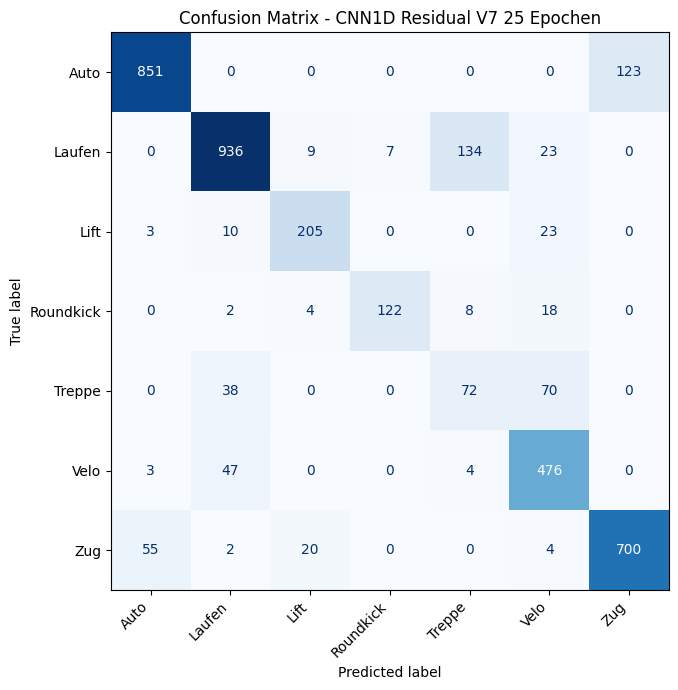

In [ ]:
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

plot_confusion_matrix(
    model = final_model,
    loader = test_loader,
    device = device,
    class_names = le.classes_,   # gibt die originalen Label-Namen wie "Zug" und "Auto"
    name = "Confusion Matrix - CNN1D Residual V7 25 Epochen",
    save_path= "Confusion_Matrix/CNN1D_Residual_v7_lr0.001_bs64_do0.4.png"
)

In [ ]:
# Modell-Gewichte speichern
torch.save(final_model.state_dict(), "../DL_Modell/CNN1D_Residual_v7_final.pth")
print("Modell gespeichert!")

Modell gespeichert!


Modell kann geladen werden mit

model = CNN1D_Residual(n_features=13, n_classes=7, dropout=0.4).to(device)
model.load_state_dict(torch.load("Models/CNN1D_Residual_v7_final.pth", map_location=device))
model.eval()

# LSTM Ansatz

Als zweites wird noch versucht mit einem LSTM Ansatz bessere Ergebnisse zu erlangen. Dies wurde vor der Überarbeitung des 1D-CNN Residual gemacht von oben. Somit war bis dahin 0.73 der beste Wert, welcher noch verbessert werden konnte. 

## Einzelversuche

Zuerst wurden einzelversuche gemacht, um hidden_size und num_layers Parameter einzustellen. 

In [12]:
lstm_attn_config = {
    "model":       "BiLSTM-best",
    "window_size": 100,
    "step_size":   50,
    "batch_size":  32,
    "lr":          0.001,
    "epochs":      25,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "dropout":     0.3,
    "hidden_size": 256,
    "num_layers":  2,
}

model_lstmattn, history_lstmattn = train(
    config      = lstm_attn_config,
    train_ds    = train_ds_lstm,
    test_ds     = test_ds_lstm,
    device      = device,
    project     = "CDL1",
    model_class = BiLSTMClassifier
)

Training: 100%|██████████| 25/25 [10:21<00:00, 24.84s/epoch, train_f1=0.973, val_f1=0.713, val_acc=0.769]


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train/acc,▁▄▅▆▇▇▇▇▇▇▇██████████████
train/f1,▁▂▄▆▆▇▇▇▇▇▇▇▇████████████
train/loss,█▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂▂▄▅▆▇████▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁
val/acc,▁▁▃▄▅▆▆█▅▇▆▇▇▆▇▆████▇█▇▇▇
val/f1,▁▁▄▆▆▆▇█▇▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇
val/loss,█▇▆▅▆▆▃▁▄▂▃▂▃▄▂▂▁▂▂▂▄▁▂▂▂
epoch,25
train/acc,0.982
train/f1,0.97322


In [13]:
# Modell-Gewichte speichern
torch.save(model_lstmattn.state_dict(), "../DL_Modell/BiLSTM_final.pth")
print("Modell gespeichert!")

Modell gespeichert!


## Parametergrid für LSTM

Es werden wieder die besten Parameter gesucht. Die hidden_size wurd zuvor mit einigen Experimenten auf 256 festgelegt, genauso wie die Anzahl Layer auf 2 gesetzt wurden. 

In [ ]:
lstm_param_grid = {
    "lr":          [0.0005, 0.0003, 0.0001],
    "batch_size":  [32, 64],
    "dropout":     [0.2, 0.3, 0.4],
}

# Alle Kombinationen erzeugen
keys, values = zip(*lstm_param_grid.items())
combinations = list(itertools.product(*values))
print(f"Gesamt: {len(combinations)} Kombinationen")

# Ergebnisse sammeln
results = []

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"\n[{i}/{len(combinations)}] {params}")

    cfg = {
        "model": "LSTM Self-Att",
        "window_size": 100,
        "step_size": 50,
        "epochs": 20,
        "n_features": 13,
        "n_classes": len(le.classes_),
        "num_layers":  2,
        "hidden_size": 256,
        **params,  # lr, batch_size, dropout werden überschrieben
    }

    model, history = train(
        config = cfg,
        train_ds = train_ds_lstm,
        test_ds = test_ds_lstm,
        device = device,
        project = "CDL1",
        model_class= LSTMAttentionClassifier
    )

    # Bestes val/f1 aus der History holen
    best_val_f1 = max(e["f1"]  for e in history["val"])
    best_val_acc = max(e["acc"] for e in history["val"])

    results.append({
        **params,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "model": model,
        "history": history,
    })

    print(f" best val/f1: {best_val_f1:.4f}  |  best val/acc: {best_val_acc:.4f}")

# Nach F1 sortieren und Top-3 ausgeben
results.sort(key=lambda x: x["best_val_f1"], reverse=True)

In [ ]:
best_model = results[0]["model"]
best_params = {k: results[0][k] for k in lstm_param_grid.keys()}
print("Beste Parameter:", best_params)
print(f"Bestes val/f1: {results[0]['best_val_f1']:.4f}")

# LSTM-Datensatz verwenden, nicht test_ds (das ist für CNN)
test_loader_lstm = DataLoader(test_ds_lstm, batch_size=64, shuffle=False)

plot_confusion_matrix(
    model       = best_model,
    loader      = test_loader_lstm,
    device      = device,
    class_names = le.classes_,
    name        = f"Confusion Matrix - LSTM Attention lr{results[0]['lr']}_bs{results[0]['batch_size']}_do{results[0]['dropout']}",
    save_path   = f"Confusion_Matrix/LSTM_Attention_lr{results[0]['lr']}_bs{results[0]['batch_size']}_do{results[0]['dropout']}.png"
)

## Resultate Gridsearch einfaches LSTM

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/ag594wc5",
    width=1100, height=600
)

## Resultate Bidirektionales LSTM

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/q13fsyh4",
    width=1100, height=600
)

# Kombination LSTM und CNN

Da die Ergebnisse von einem reinen und bidirektionalen LSTM schlechter sind, wie die eines 1D-CNNs wurde noch versucht die beiden in einem Ansatz zu kombinieren. 

In [ ]:
class CNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),              # 100 → 50
        )
        self.res = ResidualBlock(64, dropout)   # dein bestehender ResidualBlock

        self.down = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
                                          # kein MaxPool → bleibt bei 50
        )
        
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (N, T, C) → (N, C, T)
        x = self.stem(x)
        x = self.res(x)
        x = self.down(x)                 # (N, 128, 50)
        x = x.permute(0, 2, 1)          # (N, 50, 128)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(last)

In [ ]:
cnnlstm_config = {
    "model":       "CNN-LSTM",
    "window_size": 100,
    "step_size":   50,
    "batch_size":  64,
    "lr":          0.0005,
    "epochs":      20,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "dropout":     0.3,
    "hidden_size": 256,
    "num_layers":  2,
}

model_cnnlstm, history_cnnlstm = train(
    config      = cnnlstm_config,
    train_ds    = train_ds_lstm,    # LSTM-Datensatz, permute passiert intern
    test_ds     = test_ds_lstm,
    device      = device,
    project     = "CDL1",
    model_class = CNNLSTMClassifier
)

## Resultate Kombination

In [ ]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/7p71dod0",
    width=1100, height=600
)


# Fazit LSTM

Das LSTM ist bedeutend schlechter für unsere Aufgabe, wie das 1D-CNN, aus diesem Grund wurde nur das 1D-CNN noch weiter optimiert. 